In [730]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import time
import sys
import pybamm
import importlib

# # import  settings
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver3
importlib.reload(exp_pybamm_ver3)

<module 'exp_pybamm_ver3' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/exp_pybamm_ver3.py'>

In [751]:
Rk = 1e-5
def OCV(cn,cp):
    '''Calculate the open circuit voltage from the surface concentrations.
    Parameters:
    cn: surface concentration in the negative electrode non-normalized
    cp: surface concentration in the positive electrode non-normalized
    '''
    c_n = cn / cn[0]
    c_p = cp / cp[0]

    p_coefs = np.array([-5.36288590e+05,  6.86184831e+06, -3.94111561e+07,  1.33803966e+08,
 -2.97369993e+08,  4.52034948e+08, -4.75974205e+08 , 3.42794308e+08,
 -1.61601837e+08,  4.50305277e+07, -5.63211440e+06])
    n_coefs = np.array([-5.11352875e+03,  2.94235640e+04, -7.40951458e+04,  1.07407411e+05,
 -9.91884548e+04,  6.09728992e+04, -2.52768864e+04 , 6.97753127e+03,
 -1.22476269e+03,  1.22531615e+02, -4.98994630e+00])
    
    p_fit = np.poly1d(p_coefs)
    n_fit = np.poly1d(n_coefs)
    ocp_p = p_fit(c_p)
    ocp_n = n_fit(c_n)
    return ocp_p - ocp_n


def exchange_current_dens(c,k=None,K = [5,2]):
    c_reduced = c[-1,...]/ np.max(c,axis = 0)
    F = sc.physical_constants['Faraday constant'][0]
    if k is None:
        K = 0.1 / F 
    elif k == 'n':
        K = K[0] / F 
        return  np.sqrt(c_reduced * (1-c_reduced)) 
    elif k == 'p':
        K = K[1] / F 
    return np.sqrt(c_reduced * (1-c_reduced)) 


def eta_r(i,cp,cn, params,K = [0.05,0.2]):
    Ln = params['Negative electrode thickness [m]']
    Lp = params['Positive electrode thickness [m]']
    
    A = params['Electrode width [m]'] * params['Electrode height [m]']
    T = params['Initial temperature [K]']
    
    R = sc.R
    F = sc.physical_constants['Faraday constant'][0]
    jp0 = exchange_current_dens(cp,k = 'p',K=K)
    jn0 = exchange_current_dens(cn,k = 'n',K=K)

    i_app = i / A
    jn = i_app / Ln
    jp = -i_app / Lp
    return 2 * R * T / F * (np.arcsinh(jn/jn0)-np.arcsinh(jp/(jp0)))

def V_terminal(I,cp,cn, params, K = [0.05,0.2]):
    U = OCV(cn[-1,:],cp[-1,:])
    eta = eta_r(I,cp,cn,params=params, K=K)
    return U - eta

In [ ]:

#sol, model,_,params = exp_pybamm_ver3.generate_data(model='SPM', RNG = False)
sol, model,params = sim_PyBaMM.simulate(0.01)
t = np.linspace(0,sol['Time [s]'].entries[-1],1000)
V_true = V = sol.observe(model.variables['Terminal voltage [V]'])(t)
I = sol.observe(model.variables['Current [A]'])(t)
ocp_p = sol.observe(model.variables['X-averaged positive electrode open-circuit potential [V]'])(t)
ocp_n = sol.observe(model.variables['X-averaged negative electrode open-circuit potential [V]'])(t)
#cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)
#cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)
c_max = sol.observe(model.variables['Maximum positive particle concentration [mol.m-3]'])(t)
cn = sol.observe(model.variables['Negative particle surface concentration [mol.m-3]'])(t)
cp = sol.observe(model.variables['Positive particle surface concentration [mol.m-3]'])(t)
jn0_true = sol.observe(model.variables['X-averaged negative electrode exchange current density [A.m-2]'])(t)
jp0_true = sol.observe(model.variables['X-averaged positive electrode exchange current density [A.m-2]'])(t)
OCV_true = sol.observe(model.variables['Surface open-circuit voltage [V]'])(t)

T = sol.observe(model.variables[''])(t)

298.15 298.15


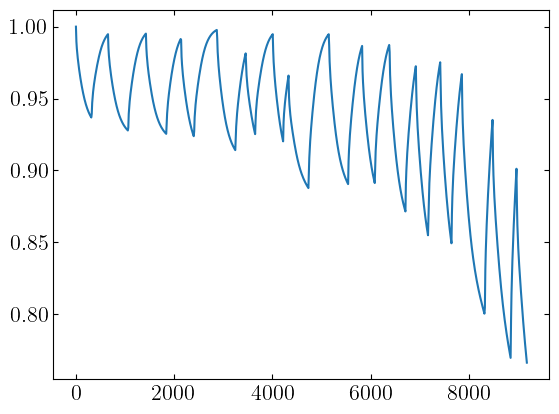

In [733]:
plt.plot(t,cn[-1,...]/ np.max(cn,axis = 0))

### Check OCV

### Check $j_{k0}$

0.003526217426566522


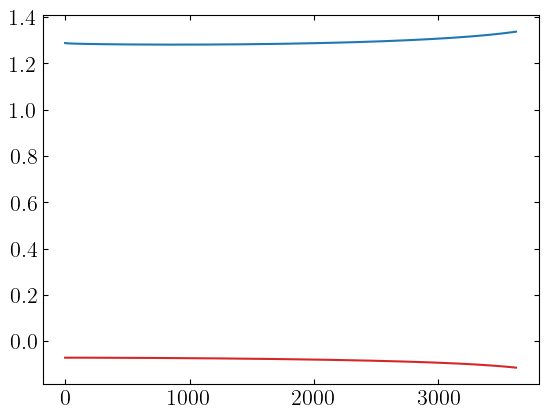

In [ ]:
R = sc.R
F = sc.physical_constants['Faraday constant'][0]

Ln = params['Negative electrode thickness [m]']
Lp = params['Positive electrode thickness [m]']
    
A = params['Electrode width [m]'] * params['Electrode height [m]']
T = params['Initial temperature [K]']

i_app = I / A
jn = i_app / Ln
jp = -i_app / Lp

eta = 2 *  R * T / F * (np.arcsinh(jn/jn0_true)-np.arcsinh(jp/(jp0_true))) 

plt.plot(t,eta,color = 'tab:blue', label = 'SPM')
plt.plot(t,sol.observe(model.variables['X-averaged reaction overpotential [V]'])(t),color = 'tab:red', label = 'SPM')


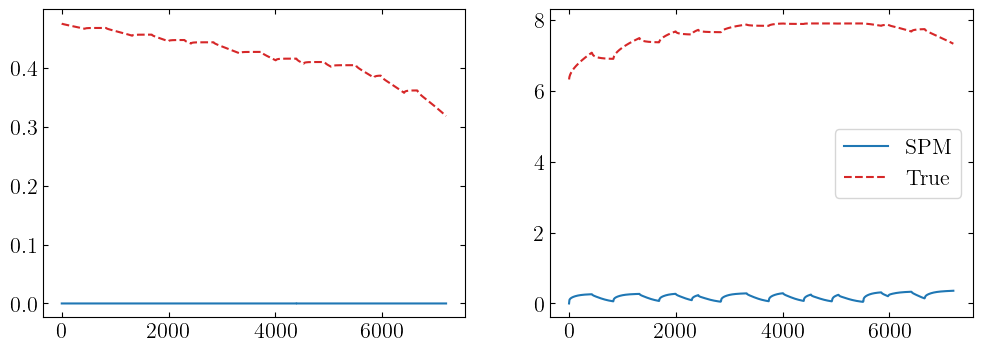

In [569]:
f, ax = plt.subplots(1,2,figsize = (12,4))

ax[0].plot(t, exchange_current_dens(cp,k = 'p'),color = 'tab:blue', label = 'SPM')
ax[0].plot(t, jp0_true,color = 'tab:red',ls = '--', label = 'True')
ax[1].plot(t, exchange_current_dens(cn,k = 'n'),color = 'tab:blue', label = 'SPM')
ax[1].plot(t, jn0_true,color = 'tab:red',ls = '--', label = 'True')
plt.legend()

### Check $\eta_r$

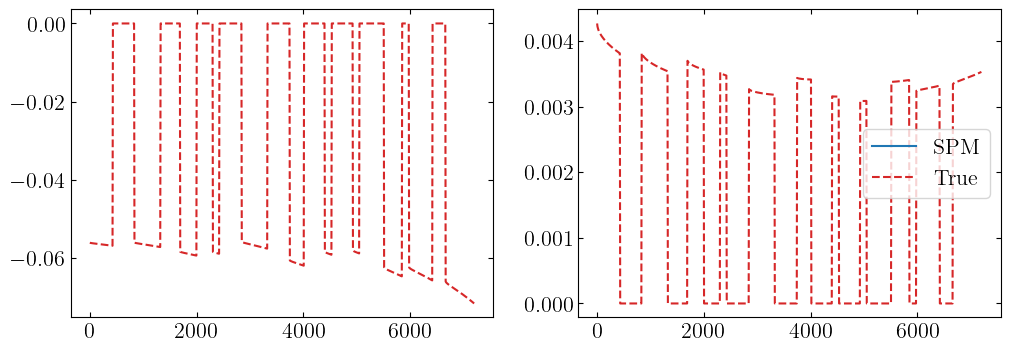

In [566]:
# eta_true_n = np.mean(sol.observe(model.variables['Negative electrode reaction overpotential [V]'])(t),axis =0)
# eta_true_p = np.mean(sol.observe(model.variables['Positive electrode reaction overpotential [V]'])(t),axis =0)
eta_true_n = sol.observe(model.variables['X-averaged battery negative reaction overpotential [V]'])(t)
eta_true_p = sol.observe(model.variables['X-averaged battery positive reaction overpotential [V]'])(t)


f, ax = plt.subplots(1,2,figsize = (12,4))
ax[0].plot(t, eta_r(I,cp,cn,params=params, K = [Kn,Kp]),color = 'tab:blue', label = 'SPM')
ax[0].plot(t, eta_true_p,color = 'tab:red',ls = '--', label = 'True')
ax[1].plot(t, eta_r(I,cp,cn,params=params, K = [Kn,Kp]),color = 'tab:blue', label = 'SPM')
ax[1].plot(t, eta_true_n,color = 'tab:red',ls = '--', label = 'True')
plt.legend()

In [567]:
Kp = 3e5
Kn = 1e8
V = V_terminal(I,cp,cn,ocp_p,ocp_n, params, K = None)
plt.plot(t, V,color = 'tab:blue', label = 'SPM')
plt.plot(t, V_true,color = 'tab:red',ls = '--', label = 'True')
plt.legend()    

TypeError: 'NoneType' object is not subscriptable